# Data Wrangling and Preprocessing

This notebook is dedicated to the data wrangling and preprocessing steps that are performed on the dataset. This is the first approach to the data, and it is important to understand the structure of the dataset. the features and the target variables. The entire process of processing the data is automatized in `/src/data_processing/processor.py`, but here we will go through the steps one by one to understand what is happening.

## 1. Librerías

We initialize the libraries that we will use in this notebook. We will use `pandas` for data manipulation, `numpy` for numerical operations, and `matplotlib` and `seaborn` for data visualization. We also import `h5py` to read the dataset, which is in HDF5 format and `scipy` for some statistical operations.

In [17]:
from pathlib import Path
import h5py
from scipy.stats import ks_2samp
import pandas as pd
import numpy as np

import matplotlib
import matplotlib.pyplot as plt

if not hasattr(matplotlib.rcParams, '_get'):
    matplotlib.rcParams._get = lambda key: matplotlib.rcParams.get(key)
%matplotlib inline

import seaborn as sns
#from kan import KAN
print("The packages were imported successfully, you can continue.")

The packages were imported successfully, you can continue.


## 2. Data Visualization

### [JetNet](https://zenodo.org/records/6975118)
The data were adquired from the JetNet dataset, which is a collection of simulated particle jets. The dataset contains information about the particles that make up each jet, as well as the properties of the jets themselves. The data is stored in HDF5 format, which allows for efficient storage and retrieval of large datasets.


**Description**

Each file has <code>particle_features</code> and <code>jet_features</code> arrays, containing the list of particles' features per jet and the corresponding jet's features, respectively.

<code>particle_features</code> is of shape [N, 30, 4] where

* N is the total number of jets,
* 30 is the max number of particles per jet, and
* 4 is the number of particle features, in order: [$\eta_{rel}$, $\phi _{rel}$, $pt_{rel}$, mask]

<code>jet_features</code> is of shape [N,4] where 4 is the number of jet features, in order: [$p_T$, $\eta$, mass, # of particles].

In this entire project, the `jet_features` are the main focus, and the `particle_features` are not used for the moment, but they could be used in the future to extract more information about the jets and improve the performance of the models. 

We start loading the data to see what it looks like.

### 2.1 Data Loading and Exploration

In [2]:
# Load the data
DATA_DIR = Path("../data") 
files_path_q = DATA_DIR / "q.hdf5"
files_path_g = DATA_DIR / "g.hdf5"

# Contents
def print_hdf5_item(name, obj):
    if isinstance(obj, h5py.Group):
        print(f' Group:{name}/')
    elif isinstance(obj, h5py.Dataset):
        print(f" Dataset: {name} (Shape: {obj.shape}, Dtype: {obj.dtype})")

try:
    with h5py.File(files_path_g, 'r') as f:
        print("--------------------------------")
        print(f"File HDF5 '{files_path_g}' opened successfully")
        print('\n Contents of the g file:')

        f.visititems(print_hdf5_item)
except FileNotFoundError:
    print(f"Error: The file '{files_path_g}' was not found. Please check the path or file name.")
except Exception as e:
    print(f"An error occurred while reading the HDF5 file: {e}")

try:
    with h5py.File(files_path_q, 'r') as f:
        print("--------------------------------")
        print(f"File HDF5 '{files_path_q}' opened successfully")
        print('\n Contents of the q file:')

        f.visititems(print_hdf5_item)
except FileNotFoundError:
    print(f"Error: The file '{files_path_q}' was not found. Please check the path or file name.")
except Exception as e:
    print(f"An error occurred while reading the HDF5 file: {e}")

--------------------------------
File HDF5 '../data/g.hdf5' opened successfully

 Contents of the g file:
 Dataset: jet_features (Shape: (177252, 4), Dtype: float32)
 Dataset: particle_features (Shape: (177252, 30, 4), Dtype: float32)
--------------------------------
File HDF5 '../data/q.hdf5' opened successfully

 Contents of the q file:
 Dataset: jet_features (Shape: (170679, 4), Dtype: float32)
 Dataset: particle_features (Shape: (170679, 30, 4), Dtype: float32)


For gluons set there are 177,252 jets and for quarks there are 170,679.

Now let's see the distribution of the features.

In [3]:
# Statistical analysis of the data

try:
    with h5py.File(files_path_q, 'r') as f:
        data_q = f['jet_features'][()]
    with h5py.File(files_path_g, 'r') as f:
        data_g = f['jet_features'][()]
    print("Data loaded successfully from both files.\n")
except FileNotFoundError as e:
    print(f"Error: {e}")
except Exception as e:
    print(f"An error occurred: {e}")

feature_names = ['pT', 'eta', 'mass', 'No. particles']
data_q = pd.DataFrame(data_q, columns=feature_names)
data_g = pd.DataFrame(data_g, columns=feature_names)
print("Primeras filas del DataFrame de quarks:")
print(data_q.head())
print("\nPrimeras filas del DataFrame de gluones:")
print(data_g.head())
print("\nFilas aleatorias del DataFrame de quarks:")
print(data_q.sample(5, random_state=42))
print("\nFilas aleatorias del DataFrame de gluones:")
print(data_g.sample(5, random_state=42))

Data loaded successfully from both files.

Primeras filas del DataFrame de quarks:
            pT       eta       mass  No. particles
0  1062.301880 -0.947938  81.601204           30.0
1  1012.602783  1.202986  51.201439           20.0
2  1003.447449 -0.838966  41.038074           25.0
3  1045.443237  0.299007  43.761703           30.0
4   991.703003 -1.197170  67.533127           30.0

Primeras filas del DataFrame de gluones:
            pT       eta        mass  No. particles
0  1068.627197 -0.464242   61.029995           30.0
1   980.443970 -1.335959   82.200760           30.0
2  1129.626831  1.582208   80.016754           30.0
3  1397.575684  0.565535   72.295326           30.0
4  1156.092285  0.042042  125.922127           30.0

Filas aleatorias del DataFrame de quarks:
                 pT       eta       mass  No. particles
147899  1025.134766  0.042613  55.110901           30.0
91158    987.748596 -0.828081  37.772957           30.0
86254    980.223267  0.353265  39.956757      

In [7]:
# Statistical summary
print("\nFeatures statistical summary of quarks:")
print(data_q.describe())

print("\nFeatures statistical summary of gluons:")
print(data_g.describe())


Features statistical summary of quarks:
                  pT            eta           mass  No. particles
count  170679.000000  170679.000000  170679.000000  170679.000000
mean     1018.766235       0.005443      58.833126      27.393030
std        91.190369       0.882865      35.321098       4.387495
min       159.331894      -2.769565       4.728777       5.000000
25%       988.237396      -0.672322      34.739328      26.000000
50%      1012.992126       0.005707      47.934082      30.000000
75%      1044.637390       0.681246      71.408005      30.000000
max      1991.338745       2.655373     320.462646      30.000000

Features statistical summary of gluons:
                  pT            eta           mass  No. particles
count  177252.000000  177252.000000  177252.000000  177252.000000
mean     1133.063599       0.000124      95.880013      29.888250
std       197.285965       0.676458      47.782547       0.968216
min       244.577972      -2.622901       8.112063       7.0

Some insights that we can extract from the data are:
- The $p_T$ feature has a wide range of values, with some jets having very high energy. This could indicate that there are some outliers in the data, which could influence the performance of the models. We will need to handle these outliers in the preprocessing step.
- The $\eta$ feature has a more narrow range of values, this could be influence for the isotropy of the jets, which is a property that we will need to consider in the modeling step.
- The mass feature also has a wide range of values, with some jets having very high mass. This could also indicate the presence of outliers in the data, which we will need to handle in the preprocessing step.
- The number of particles feature has a more narrow range of values, with most jets having between 0 and 30 particles. This could indicate that there are some jets with very few particles, which could be difficult to classify.

Even there are some outliers in the data, we will not remove them because they could be important for the classification task, and we will handle them in the preprocessing step.

In [8]:
print("*-------------------------------------------*")
print("\nDataFrame information of gluons:")
data_g.info()

print("*-------------------------------------------*")
print("\nDataFrame information of quarks:")
data_q.info()

*-------------------------------------------*

DataFrame information of gluons:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 177252 entries, 0 to 177251
Data columns (total 4 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   pT             177252 non-null  float32
 1   eta            177252 non-null  float32
 2   mass           177252 non-null  float32
 3   No. particles  177252 non-null  float32
dtypes: float32(4)
memory usage: 2.7 MB
*-------------------------------------------*

DataFrame information of quarks:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170679 entries, 0 to 170678
Data columns (total 4 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   pT             170679 non-null  float32
 1   eta            170679 non-null  float32
 2   mass           170679 non-null  float32
 3   No. particles  170679 non-null  float32
dtypes: float32(4)
memory usage: 2.6 MB


There are not missing values in the dataset. There could be some duplicated but we will mantain it because in the generation of the dataset, some features values are repeated for different jets, so we will not consider it as duplicated data.

### 2.2 Raw data visualization

Now we have a better understanding of the data, we can visualize it to see if there are any patterns or relationships between the features and the target variable. We will use `seaborn` to create some plots to visualize the data. We will start with a pairplot to see the relationships between the features and the target variable.

In [18]:
# Pair plot to see relationships function
def plot_pairwise_relationships(df1, df2, feature_names):
    df1['label'] = 'Quarks'
    df2['label'] = 'Gluones'
    combined_df = pd.concat([df1, df2], ignore_index=True)
    sns.pairplot(combined_df, hue='label', vars=feature_names, diag_kind='kde', palette={'Quarks': 'blue', 'Gluones': 'red'})
    plt.suptitle('Relationships between features of Quarks and Gluons', y=1.02)
    plt.show()
    # Remove the label column to avoid side effects
    df1.drop(columns=['label'], inplace=True)
    df2.drop(columns=['label'], inplace=True)

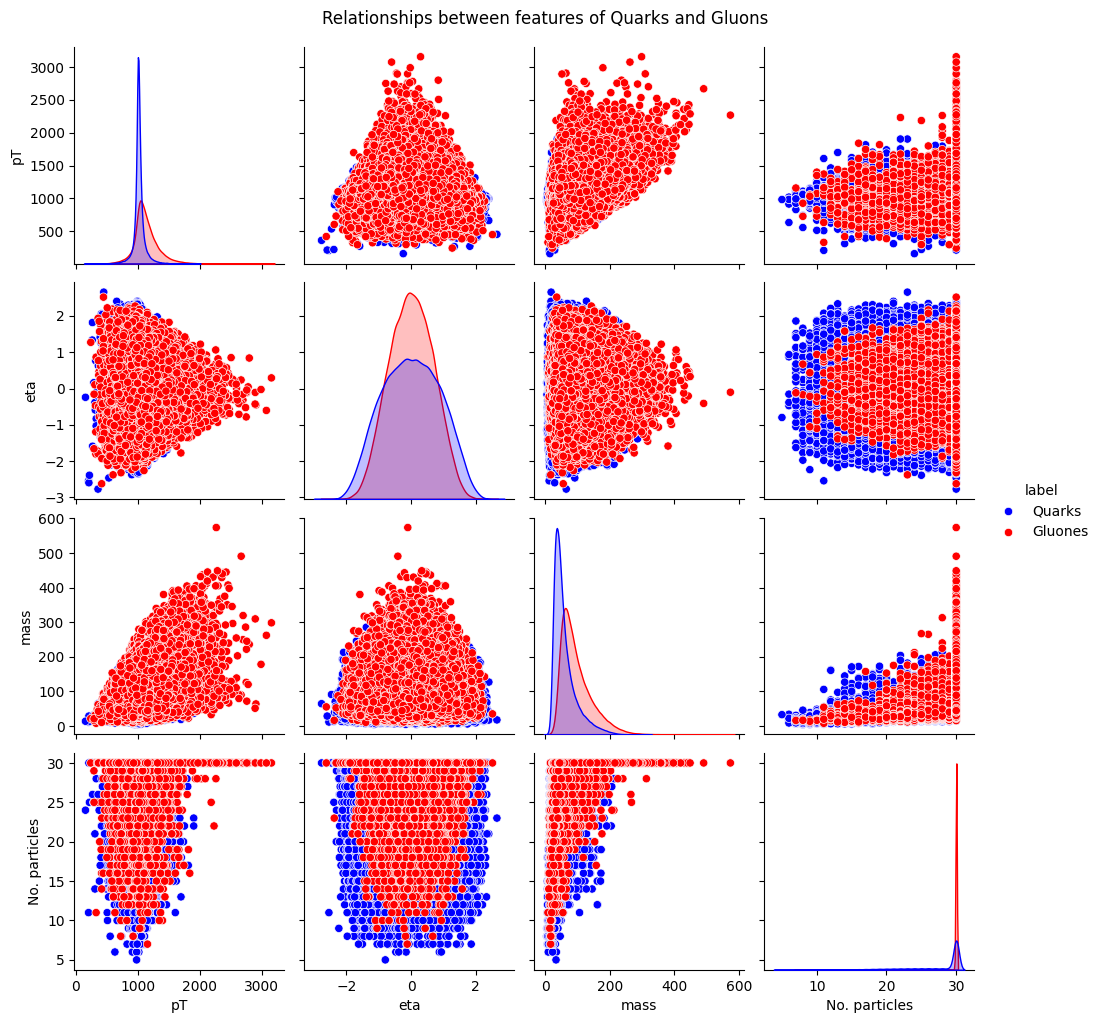

In [19]:
# plot_pairwise_relationships application
feature_names = ['pT', 'eta', 'mass', 'No. particles']
plot_pairwise_relationships(data_q, data_g, feature_names)

From the graphs we can see that there is a positive relationship between $p_T$ and mass, which is expected because the mass of a jet is related to its energy. We can also see a positive relationship between the number of particles and the mass, which is also expected because the more particles a jet has, the more massive it is. Other insights that we can extract from the data are:
- The $p_T$ feature has a bit different distribution for quarks and gluons, with gluons having a wider and greater mean value than quarks. This could indicate that $p_T$ is an important feature for the classification task.
- The $\eta$ feature has a similar distribution for quarks and gluons, with a mean value close to 0. This could indicate that $\eta$ is not an important feature for the classification task.
- The mass feature has a bit different distribution for quarks and gluons. In a similar way to $p_T$, gluons have a wider and greater mean value than quarks. This could indicate that mass is an important feature for the classification task.
- The number of particles feature has a similar distribution for quarks and gluons, with most jets having 30 particles. This could indicate that the number of particles is not an important feature for the classification task.

Now we continue with box plots to see the distribution of each feature for quarks and gluons.

In [35]:
# box plots function
def box_plots_grid(df1, df2, feature_names):
    # Create local copies with .assign to avoid side effects
    df1_labeled = df1.assign(label='Quarks')
    df2_labeled = df2.assign(label='Gluones')
    combined_df = pd.concat([df1_labeled, df2_labeled], ignore_index=True)
    
    # Set up the grid: 1 row, N columns (one per feature)
    n_features = len(feature_names)
    fig, axes = plt.subplots(1, n_features, figsize=(4 * n_features, 5), sharey=False)
    
    # In case only one feature is passed, ensure axes is an array
    if n_features == 1:
        axes = [axes]
        
    # Consistent color palette
    colors = {'Quarks': 'blue', 'Gluones': 'red'}
    
    # Iterate over each feature and its respective subplot (ax)
    for ax, feature in zip(axes, feature_names):
        sns.boxplot(
            x='label', 
            y=feature, 
            data=combined_df, 
            palette=colors, 
            ax=ax,
            fliersize=3  # Size of the outlier points (smaller to avoid clutter)
        )
        ax.set_title(f'{feature} Distribution', fontsize=14, fontweight='bold')
        ax.set_xlabel('')  # Remove repetitive X-axis text
        ax.set_ylabel(feature, fontsize=12)
        ax.tick_params(axis='x', labelsize=14)
        ax.tick_params(axis='y', labelsize=11)
        ax.grid(axis='y', linestyle='--', alpha=0.7) # Subtle horizontal grid only
        
    plt.suptitle('Outlier Analysis for Quarks and Gluons', y=1.05, fontsize=16, fontweight='bold')
    plt.tight_layout() # Automatically adjust spacing between plots
    plt.show()

/tmp/ipykernel_6243/3547887610.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_6243/3547887610.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_6243/3547887610.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_6243/3547887610.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


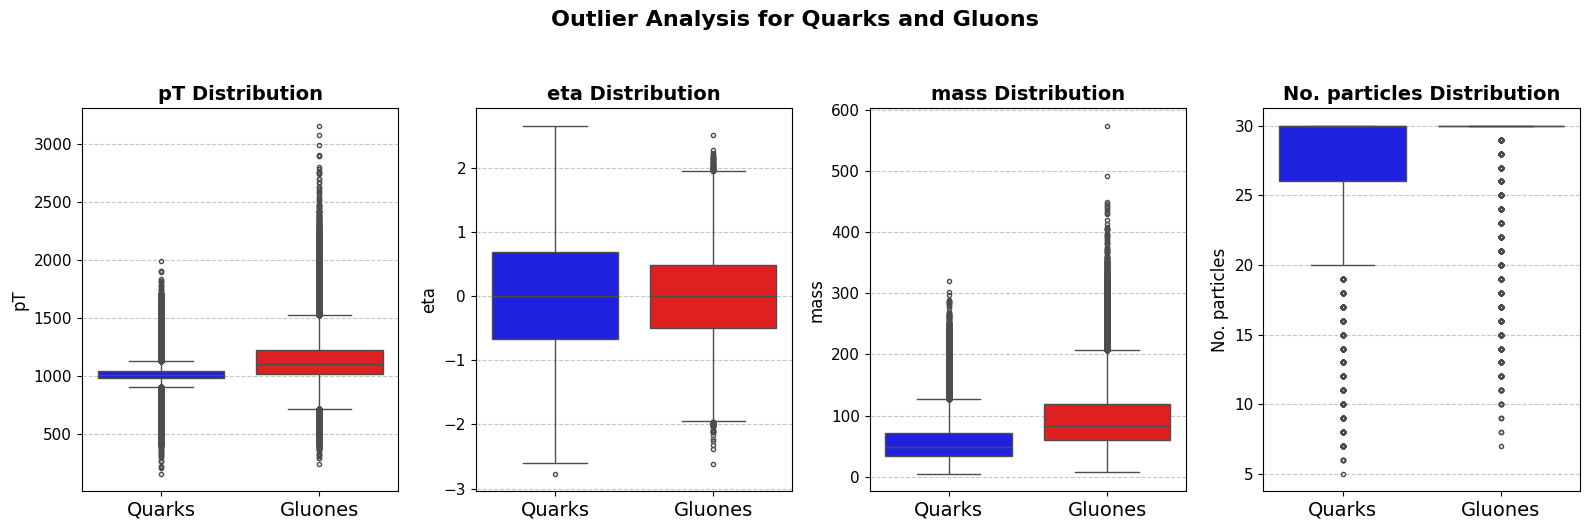

In [36]:
# plot_box_plots application
box_plots_grid(data_q, data_g, feature_names)

This box plot shows $p_T$ and mass have a lot of outliers, which could influence the performance of the models, something that we already thought during the previos explorations. The number of particles features is concentrated in the value of 30, which is the maximum number of particles per jet.

Let's see a correlation heatmap to see the correlation between the features and the target variable.

In [37]:
# Correlation matrix function
def plot_correlation_matrix(df1, df2, feature_names):
    # Create local copies assigning the numeric target (1 for Quarks, 0 for Gluons)
    df1_target = df1[feature_names].assign(is_quark=1)
    df2_target = df2[feature_names].assign(is_quark=0)
    
    # Combine both datasets
    combined_df = pd.concat([df1_target, df2_target], ignore_index=True)
    
    # Calculate the correlation matrix including 'is_quark'
    corr_matrix = combined_df.corr()
    
    # Plot a single larger heatmap for better readability
    plt.figure(figsize=(9, 7))
    
    sns.heatmap(
        corr_matrix, 
        annot=True, 
        fmt=".2f", 
        cmap='coolwarm', 
        vmin=-1, 
        vmax=1,
        linewidths=0.5,
        annot_kws={"size": 12}  # Enlarge the numbers inside the cells
    )
    
    # Adjust the size of the axis labels
    plt.xticks(fontsize=12, rotation=45, ha='right')
    plt.yticks(fontsize=12)
    
    plt.title('Global Correlation Matrix with Target Variable (is_quark)', fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()

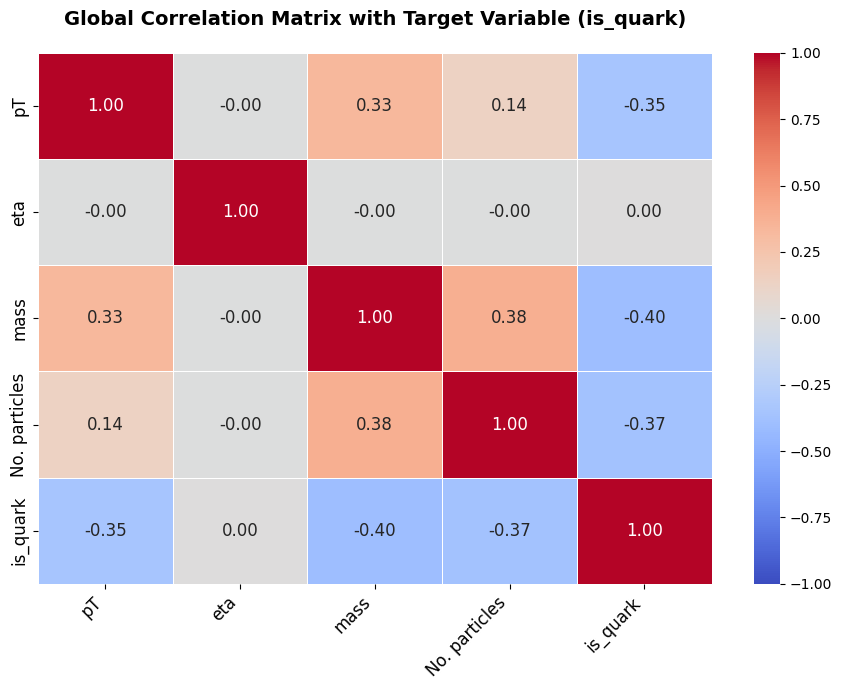

In [41]:
# Correlation matrix function application
plot_correlation_matrix(data_q, data_g, feature_names)

Here we can confirm that $p_T$, number of particles, and mass are important features for the classification task, while $\eta$ is not an important feature.

The negative relationship between the features and the target variable indicates that as the value of the feature increases, the likelihood of the jet being classified as a quark decreases, and vice versa for gluons. This is consistent with our previous observations from the pairplot and box plots, where we saw that quarks tend to have lower values of $p_T$ and mass compared to gluons. The number of particles also shows a negative relationship with the target variable, which could indicate that jets with more particles are more likely to be classified as gluons. Overall, these insights suggest that $p_T$, mass, and number of particles are important features for distinguishing between quarks and gluons in this dataset.

### 2.3 Hypothesis Testing

With the previous visualizations we have seen that $p_T$, mass, and number of particles are important features for the classification task. Now we will perform some hypothesis testing to confirm if there are any statistically significant differences between the features for quarks and gluons. We will use the t-test, k-S to compare the means of the features for quarks and gluons. 
The null hypothesis is that there is no difference in the means of the features for quarks and gluons, while the alternative hypothesis is that there is a difference in the means of the features for quarks and gluons. We will use a significance level of 0.05 to determine if we reject or fail to reject the null hypothesis.

In [34]:
# K-S test function definition
def ks_test_feature_distributions(df1, df2, feature_names):
    results = {}
    for feature in feature_names:
        stat, p_value = ks_2samp(df1[feature], df2[feature])
        results[feature] = {'K-S Statistic': stat, 'p-value': p_value}
        print(f'\nFeature: {feature} | K-S Statistic: {stat:.4f} | p-value: {p_value:.4f}')
        if p_value < 0.01:
            print("  -> ¡Estadísticamente diferentes!")
        else:
            print("  -> Indistinguibles estadísticamente.")
    return results

$\vert 0 \rangle$

In [35]:
# KS test function application
ks_results = ks_test_feature_distributions(df_q, df_g, feature_names)


Feature: pT | K-S Statistic: 0.4382 | p-value: 0.0000
  -> ¡Estadísticamente diferentes!

Feature: eta | K-S Statistic: 0.0838 | p-value: 0.0000
  -> ¡Estadísticamente diferentes!

Feature: mass | K-S Statistic: 0.4204 | p-value: 0.0000
  -> ¡Estadísticamente diferentes!

Feature: No. particles | K-S Statistic: 0.3392 | p-value: 0.0000
  -> ¡Estadísticamente diferentes!


In [36]:
# prueba de hipotesis usando el test 
from scipy.stats import norm 
def z_test_feature_means(df1, df2, feature_names):
    results = {}
    for feature in feature_names:
        mean1, mean2 = df1[feature].mean(), df2[feature].mean()
        std1, std2 = df1[feature].std(), df2[feature].std()
        n1, n2 = len(df1), len(df2)
        pooled_std = np.sqrt(((n1 - 1) * std1**2 + (n2 - 1) * std2**2) / (n1 + n2 - 2))
        z_statistic = (mean1 - mean2) / (pooled_std * np.sqrt(1/n1 + 1/n2))
        p_value = 2 * (1 - norm.cdf(abs(z_statistic)))  # Two-tailed test
        results[feature] = {'Z-Statistic': z_statistic, 'p-value': p_value}
        print(f'\nFeature: {feature} | Z-Statistic: {z_statistic:.4f} | p-value: {p_value:.4f}')
        if p_value < 0.01:
            print("  -> ¡Medias significativamente diferentes!")
        else:
            print("  -> Medias no significativamente diferentes.")
    return results

In [37]:
# prueba de hipotesis usando el test z
resultado = z_test_feature_means(df_q, df_g, feature_names)



Feature: pT | Z-Statistic: -217.9743 | p-value: 0.0000
  -> ¡Medias significativamente diferentes!

Feature: eta | Z-Statistic: 1.9992 | p-value: 0.0456
  -> Medias no significativamente diferentes.

Feature: mass | Z-Statistic: -259.2819 | p-value: 0.0000
  -> ¡Medias significativamente diferentes!

Feature: No. particles | Z-Statistic: -233.6010 | p-value: 0.0000
  -> ¡Medias significativamente diferentes!


In [38]:
# prueba de hipotesis usando U de Mann-Whitney
from scipy.stats import mannwhitneyu
def mann_whitney_u_test(df1, df2, feature_names):
    results = {}
    for feature in feature_names:
        stat, p_value = mannwhitneyu(df1[feature], df2[feature], alternative='two-sided')
        results[feature] = {'U Statistic': stat, 'p-value': p_value}
        print(f'\nFeature: {feature} | U Statistic: {stat:.4f} | p-value: {p_value:.4f}')
        if p_value < 0.01:
            print("  -> ¡Distribuciones significativamente diferentes!")
        else:
            print("  -> Distribuciones no significativamente diferentes.")
    return results

# prueba de hipotesis usando U de Mann-Whitney
mann_whitney_results = mann_whitney_u_test(df_q, df_g, feature_names)


Feature: pT | U Statistic: 8228496174.5000 | p-value: 0.0000
  -> ¡Distribuciones significativamente diferentes!

Feature: eta | U Statistic: 15181316511.0000 | p-value: 0.0647
  -> Distribuciones no significativamente diferentes.

Feature: mass | U Statistic: 6917573127.5000 | p-value: 0.0000
  -> ¡Distribuciones significativamente diferentes!

Feature: No. particles | U Statistic: 9967324901.5000 | p-value: 0.0000
  -> ¡Distribuciones significativamente diferentes!


In [31]:
# distancia de wasserstein
from scipy.stats import wasserstein_distance
def wasserstein_distance_test(df1, df2, feature_names):
    results = {}
    for feature in feature_names:
        distance = wasserstein_distance(df1[feature], df2[feature])
        results[feature] = {'Wasserstein Distance': distance}
        print(f'\nFeature: {feature} | Wasserstein Distance: {distance:.4f}')
    return results

# distancia de wasserstein
wasserstein_results = wasserstein_distance_test(df_q, df_g, feature_names)


Feature: pT | Wasserstein Distance: 120.7424

Feature: eta | Wasserstein Distance: 0.1834

Feature: mass | Wasserstein Distance: 37.0469

Feature: No. particles | Wasserstein Distance: 2.4952


## 3. Data preprocessing

In [5]:
# Quarks
print("\n*-------------------------------------------*")
print("Loading and preprocessing Quarks' data")
try: 
    with h5py.File(ruta_archivos_q, 'r') as f_q:
        data_q_jets = f_q['jet_features'][()]
        X_q = data_q_jets[:, :] # the 4 features
        print(f"Jets loaded and processesed. (Shape: {X_q.shape})")
        y_q = np.ones(X_q.shape[0], dtype=int)
except FileNotFoundError:
    print(f"Error: the file '{ruta_archivos_q}' didn't find. Please, verify name and path.")
    exit()

# Gluons
print("\n*-------------------------------------------*")
print("Loading and preprocessing Gluons' data")
try: 
    with h5py.File(ruta_archivos_g, 'r') as f_g:
        data_g_jets = f_g['jet_features'][()]
        X_g = data_g_jets[:, :] # the 4 features
        print(f"Jets loaded and processesed. (Shape: {X_g.shape})")
        y_g = np.zeros(X_g.shape[0], dtype=int)
except FileNotFoundError:
    print(f"Error: the file '{ruta_archivos_g}' didn't find. Please, verify name and path.")
    exit()


*-------------------------------------------*
Loading and preprocessing Quarks' data
Jets loaded and processesed. (Shape: (170679, 4))

*-------------------------------------------*
Loading and preprocessing Gluons' data
Jets loaded and processesed. (Shape: (177252, 4))


<b>Train, validation and test set</b>

In [6]:
# Train, validation and test sets
X_total = np.vstack((X_q, X_g))
Y_total = np.hstack((y_q, y_g))

print(f"Combined data (X_total) shape: {X_total.shape}" )
print(f"Combined data (y_total) shape: {Y_total.shape}" )

Combined data (X_total) shape: (347931, 4)
Combined data (y_total) shape: (347931,)


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch

In [8]:
X_train, X_val_test, y_train, y_val_test = train_test_split(
    X_total, Y_total, test_size=0.3, random_state=42, stratify=Y_total)

X_val, X_test, y_val, y_test = train_test_split(
    X_val_test, y_val_test, test_size=0.5, random_state=42, stratify=y_val_test)

print("--Final datasets (70 % train, 15 % val, 15 % test)---\n")

print(f"Shapes ANTES de la normalización:")
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"y_val shape: {y_val.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

--Final datasets (70 % train, 15 % val, 15 % test)---

Shapes ANTES de la normalización:
X_train shape: (243551, 4)
y_train shape: (243551,)
X_val shape: (52190, 4)
y_val shape: (52190,)
X_test shape: (52190, 4)
y_test shape: (52190,)


In [9]:
# Logarithm transformation for 'pt' and 'mass'

print("\nApplying logarithm transformation to 'pT' and 'mass' features")
X_train_log = np.copy(X_train)
X_val_log = np.copy(X_val)
X_test_log = np.copy(X_test)

# Apply log1p to 'pT'
X_train_log[:, 0] = np.log1p(X_train_log[:, 0])  
X_val_log[:, 0] = np.log1p(X_val_log[:, 0])
X_test_log[:, 0] = np.log1p(X_test_log[:, 0])

# Apply log1p to 'mass'
X_train_log[:, 1] = np.log1p(X_train_log[:, 1])  
X_val_log[:, 1] = np.log1p(X_val_log[:, 1])
X_test_log[:, 1] = np.log1p(X_test_log[:, 1])


Applying logarithm transformation to 'pT' and 'mass' features


C:\Users\jltg_\AppData\Local\Temp\ipykernel_7564\1208823515.py:14: RuntimeWarning: invalid value encountered in log1p
  X_train_log[:, 1] = np.log1p(X_train_log[:, 1])
C:\Users\jltg_\AppData\Local\Temp\ipykernel_7564\1208823515.py:15: RuntimeWarning: invalid value encountered in log1p
  X_val_log[:, 1] = np.log1p(X_val_log[:, 1])
C:\Users\jltg_\AppData\Local\Temp\ipykernel_7564\1208823515.py:16: RuntimeWarning: invalid value encountered in log1p
  X_test_log[:, 1] = np.log1p(X_test_log[:, 1])


In [10]:
#2. Standardization with StandardScaler
print("\nStandardizing features with StandardScaler...")
scaler = StandardScaler()
X_train_norm = scaler.fit_transform(X_train_log)

X_val_norm = scaler.transform(X_val_log)
X_test_norm = scaler.transform(X_test_log)


Standardizing features with StandardScaler...


In [11]:
print(f"Shapes DESPUÉS de la normalización:")
print(f"X_train_norm shape: {X_train_norm.shape}")
print(f"X_val_norm shape: {X_val_norm.shape}")
print(f"X_test_norm shape: {X_test_norm.shape}")

Shapes DESPUÉS de la normalización:
X_train_norm shape: (243551, 4)
X_val_norm shape: (52190, 4)
X_test_norm shape: (52190, 4)


In [50]:
# Conversion to Tensors
X_train_tensor = torch.from_numpy(X_train_norm).float()
y_train_tensor = torch.from_numpy(y_train).float()

X_val_tensor = torch.from_numpy(X_val_norm).float()
y_val_tensor = torch.from_numpy(y_val).float()

X_test_tensor = torch.from_numpy(X_test_norm).float()
y_test_tensor = torch.from_numpy(y_test).float()

if y_train_tensor.ndim == 1:
    y_train_tensor = y_train_tensor.unsqueeze(1)
    y_val_tensor = y_val_tensor.unsqueeze(1)
    y_test_tensor = y_test_tensor.unsqueeze(1)

print(f"X_train_tensor shape: {X_train_tensor.shape}")
print(f"y_train_tensor shape: {y_train_tensor.shape}")

X_train_tensor shape: torch.Size([243551, 4])
y_train_tensor shape: torch.Size([243551, 1])



Visualización de los datos normalizados:


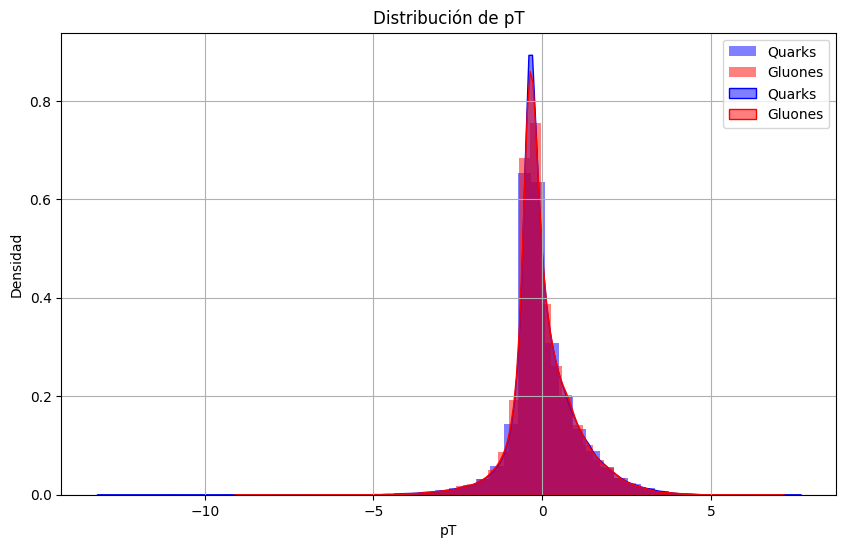

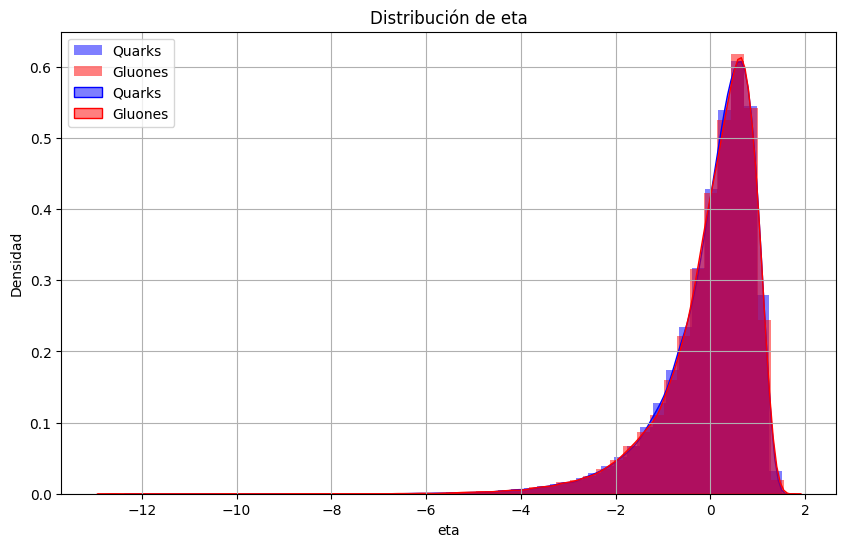

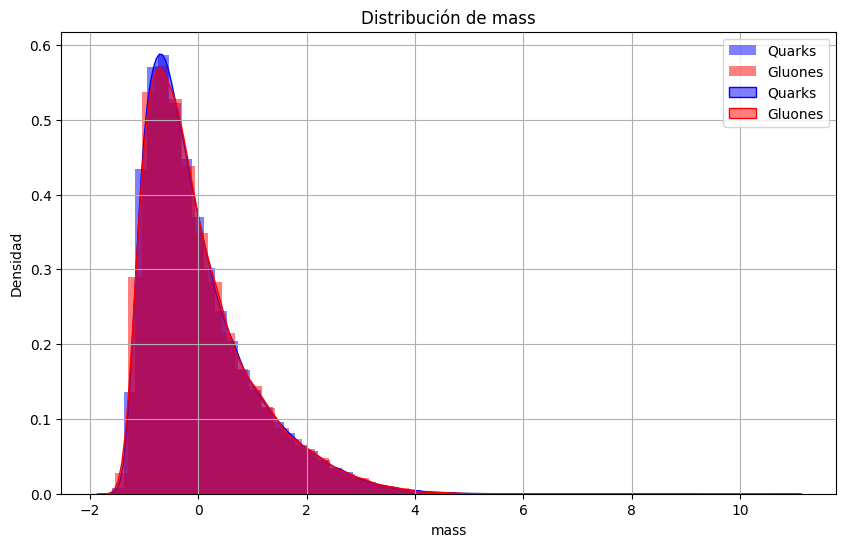

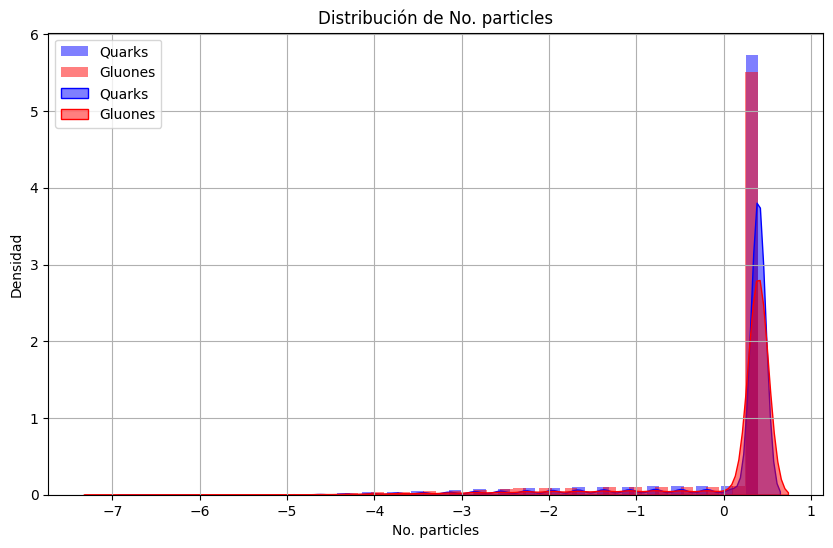

In [57]:
# Visualización de los datos normalizados
print("\nVisualización de los datos normalizados:")
feature_names = ['pT', 'eta', 'mass', 'No. particles']
plot_feature_distributions(pd.DataFrame(X_train_norm, columns=feature_names), pd.DataFrame(X_val_norm, columns=feature_names), feature_names)

In [40]:
# Descripción estadística de los conjuntos normalizados
print("\nDescripción estadística de los conjuntos normalizados:")
print("\nConjunto de entrenamiento:")
print(pd.DataFrame(X_train_norm, columns=feature_names).describe())
print("\nConjunto de validación:")
print(pd.DataFrame(X_val_norm, columns=feature_names).describe())


Descripción estadística de los conjuntos normalizados:

Conjunto de entrenamiento:
                 pT           eta          mass  No. particles
count  2.435510e+05  2.435510e+05  2.435510e+05   2.435510e+05
mean  -5.137407e-09  2.036167e-09 -4.456074e-09  -6.977789e-09
std    1.000002e+00  1.000002e+00  1.000002e+00   1.000002e+00
min   -1.299398e+01 -4.373102e+00 -1.581022e+00  -7.004516e+00
25%   -4.601670e-01 -7.244510e-01 -7.295366e-01   3.942013e-01
50%   -1.868143e-01 -2.854206e-02 -2.672516e-01   3.942013e-01
75%    4.153257e-01  7.093776e-01  4.629344e-01   3.942013e-01
max    7.446764e+00  3.859628e+00  1.076856e+01   3.942013e-01

Conjunto de validación:
                 pT           eta          mass  No. particles
count  52190.000000  52190.000000  52190.000000   52190.000000
mean       0.003824     -0.003753     -0.005188       0.000894
std        1.001939      0.996629      0.994262       1.004239
min      -10.701032     -3.739028     -1.526384      -6.708567
25%      

## 4. Final results

In [39]:
#classic_data = pd.read_csv("reports/seed_20/summary_classical_baseline.csv")

In [ ]:
classic_data

,Seed,Accuracy,AUC,F1-Score,Params,Train Time (s),Inference Time (s)
0,seed_123,0.787373,0.873347,0.791555,148,2040.291956,0.109350
1,seed_20,0.785859,0.873024,0.790075,148,3170.622169,0.104693
2,seed_30,0.786147,0.873065,0.790345,148,4101.689223,0.100607
3,seed_42,0.787507,0.873381,0.790636,148,2393.240655,0.099777
4,seed_50,0.787450,0.873358,0.791253,148,2918.063360,0.100980
5,seed_60,0.786013,0.873013,0.790249,148,4528.133023,0.105069
6,seed_73,0.787354,0.873364,0.791415,148,2059.428332,0.102772
7,seed_8,0.784461,0.871650,0.786648,148,2923.977048,0.105934
8,seed_88,0.785955,0.873063,0.790244,148,3740.079549,0.106253
9,seed_999,0.785898,0.873074,0.790104,148,3706.452878,0.104617


In [ ]:
for name in classic_data.columns:
    classic_data.rename(columns={name: name.lower()}, inplace=True)
    classic_data.rename(columns={name: name.strip()}, inplace=True)
    classic_data.rename(columns={name: name.replace(" ", "_")}, inplace=True)

print(classic_data.columns)

Index(['seed', 'accuracy', 'auc', 'f1-score', 'params', 'train_time_(s)',
       'inference_time_(s)'],
      dtype='object')


In [ ]:
classic_data['train_time_(min)'] = classic_data['train_time_(s)']/60.

In [ ]:
classic_data.describe()

,accuracy,auc,f1-score,params,train_time_(s),inference_time_(s),train_time_(min)
count,10.000000,10.000000,10.000000,10.0,10.000000,10.000000,10.000000
mean,0.786402,0.873034,0.790252,148.0,3158.197819,0.104005,52.636630
std,0.000995,0.000511,0.001385,0.0,853.809379,0.002971,14.230156
min,0.784461,0.871650,0.786648,148.0,2040.291956,0.099777,34.004866
25%,0.785912,0.873034,0.790139,148.0,2524.446331,0.101428,42.074106
50%,0.786080,0.873070,0.790297,148.0,3047.299609,0.104655,50.788327
75%,0.787368,0.873356,0.791099,148.0,3731.672882,0.105718,62.194548
max,0.787507,0.873381,0.791555,148.0,4528.133023,0.109350,75.468884


In [ ]:
classic_data.iloc[1,2:].describe()

count     5.000000
unique    5.000000
top       0.873024
freq      1.000000
Name: 1, dtype: float64